In [3]:
# ============================================
# WATER POTABILITY PREDICTION PROJECT
# Step 1: Import Required Libraries
# ============================================

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning - Data Splitting
from sklearn.model_selection import train_test_split

# Machine Learning - Missing Value Handling
from sklearn.impute import SimpleImputer

# Machine Learning - Feature Scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning - Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

Step 2: Load the Dataset

In [4]:

# ============================================
# Step 2: Load the Dataset
# ============================================

# Load the water potability CSV dataset
df = pd.read_csv("../data/water_potability.csv")

# Display the first 5 rows
print(df.head())

# Check the number of rows and columns
print("\nDataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

Dataset Shape: (3276, 10)

Column Names:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidit

In [5]:
# ============================================
# Step 3: Explore the Dataset
# ============================================

# Display information about the dataset
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Check the number of duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Check the distribution of the target variable
print("\nPotability Distribution:")
print(df["Potability"].value_counts())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

Statistical Summary:
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761

In [6]:
# ============================================
# Step 4: Data Cleaning and Preprocessing
# ============================================

# Check the data types of all columns
print("Data Types Before Cleaning:")
print(df.dtypes)


# Convert the pH column to numeric
# Invalid values will be converted to NaN
df["ph"] = pd.to_numeric(df["ph"], errors="coerce")


# Check missing values after conversion
print("\nMissing Values After Conversion:")
print(df.isnull().sum())


# Define the feature columns
feature_columns = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]


# Remove duplicate rows
df = df.drop_duplicates()


# Check the dataset shape after removing duplicates
print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


# Check data types after cleaning
print("\nData Types After Cleaning:")
print(df.dtypes)

Data Types Before Cleaning:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Missing Values After Conversion:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Dataset Shape After Removing Duplicates:
(3276, 10)

Data Types After Cleaning:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


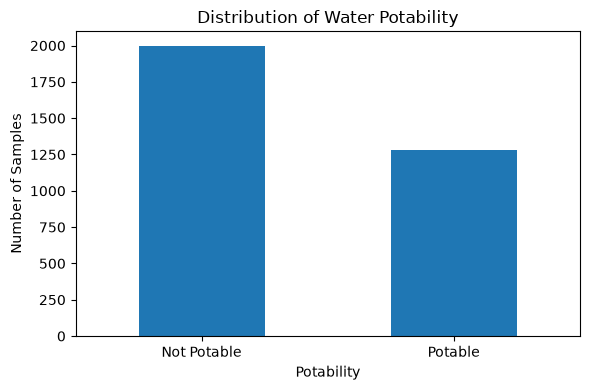

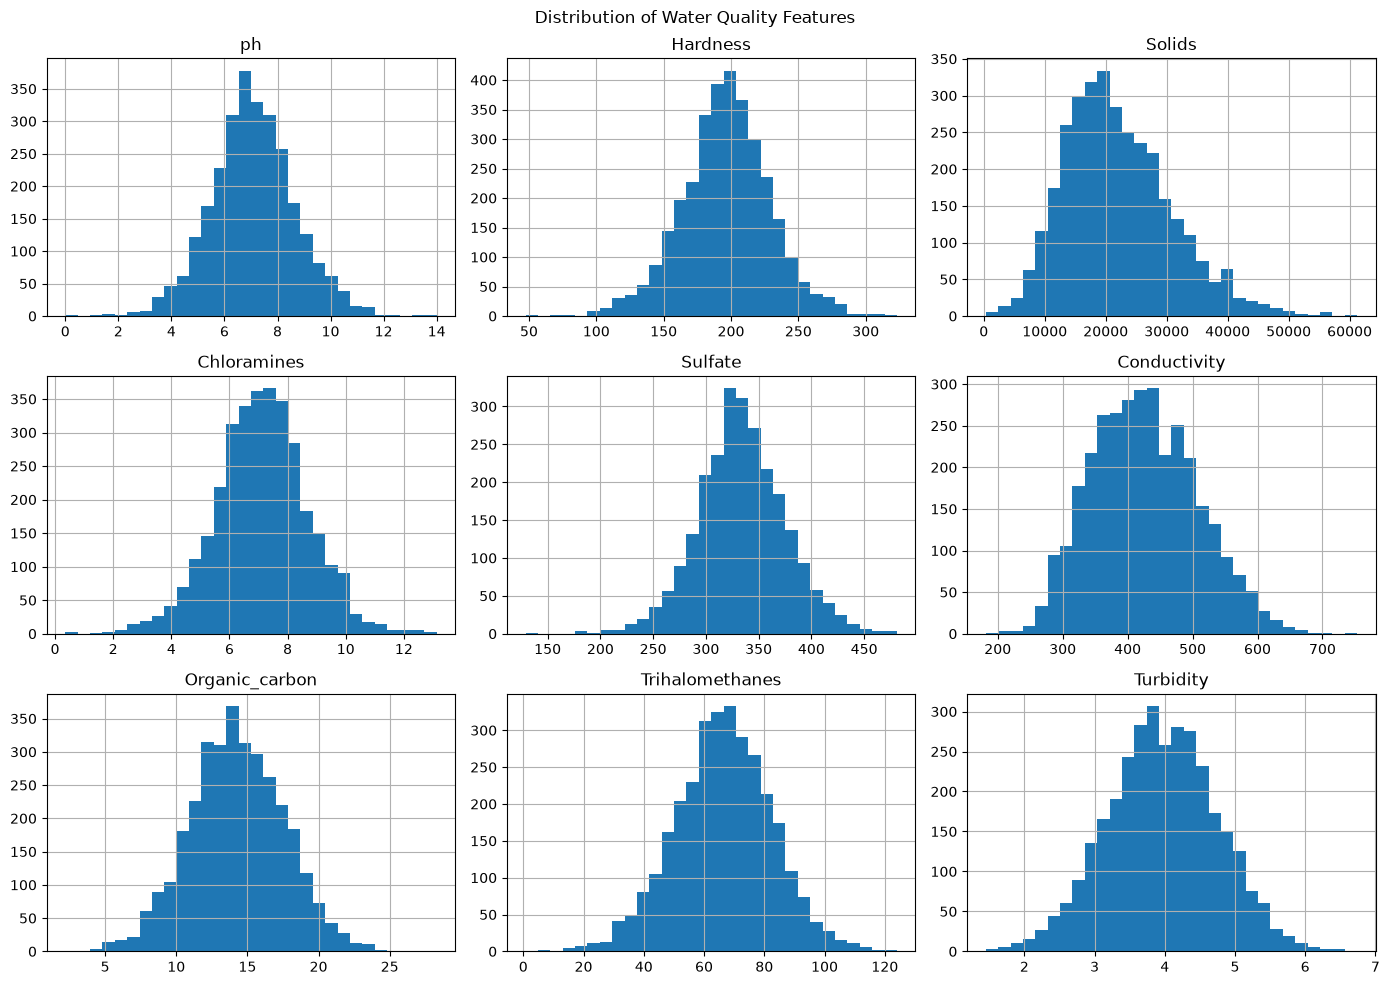

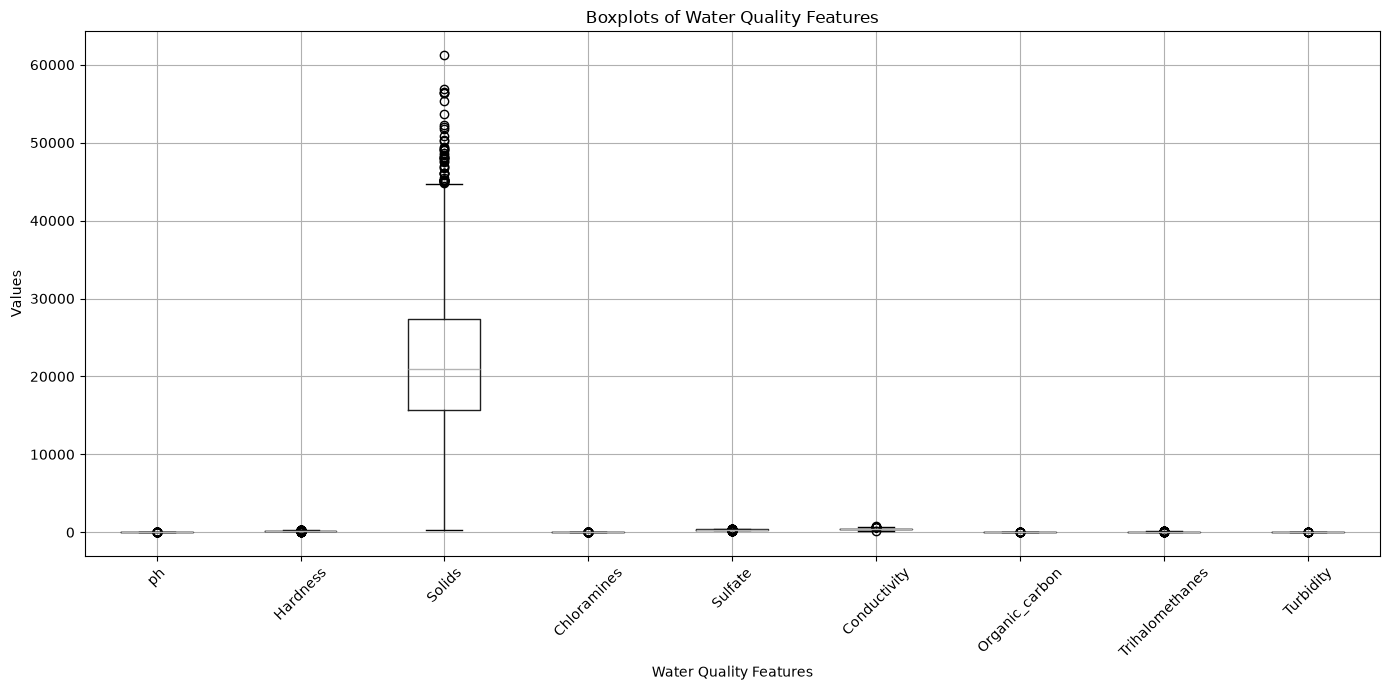

Correlation Matrix:
                       ph  Hardness    Solids  Chloramines   Sulfate  \
ph               1.000000  0.082096 -0.089288    -0.034350  0.018203   
Hardness         0.082096  1.000000 -0.046899    -0.030054 -0.106923   
Solids          -0.089288 -0.046899  1.000000    -0.070148 -0.171804   
Chloramines     -0.034350 -0.030054 -0.070148     1.000000  0.027244   
Sulfate          0.018203 -0.106923 -0.171804     0.027244  1.000000   
Conductivity     0.018614 -0.023915  0.013831    -0.020486 -0.016121   
Organic_carbon   0.043503  0.003610  0.010242    -0.012653  0.030831   
Trihalomethanes  0.003354 -0.013013 -0.009143     0.017084 -0.030274   
Turbidity       -0.039057 -0.014449  0.019546     0.002363 -0.011187   
Potability      -0.003556 -0.013837  0.033743     0.023779 -0.023577   

                 Conductivity  Organic_carbon  Trihalomethanes  Turbidity  \
ph                   0.018614        0.043503         0.003354  -0.039057   
Hardness            -0.023915    

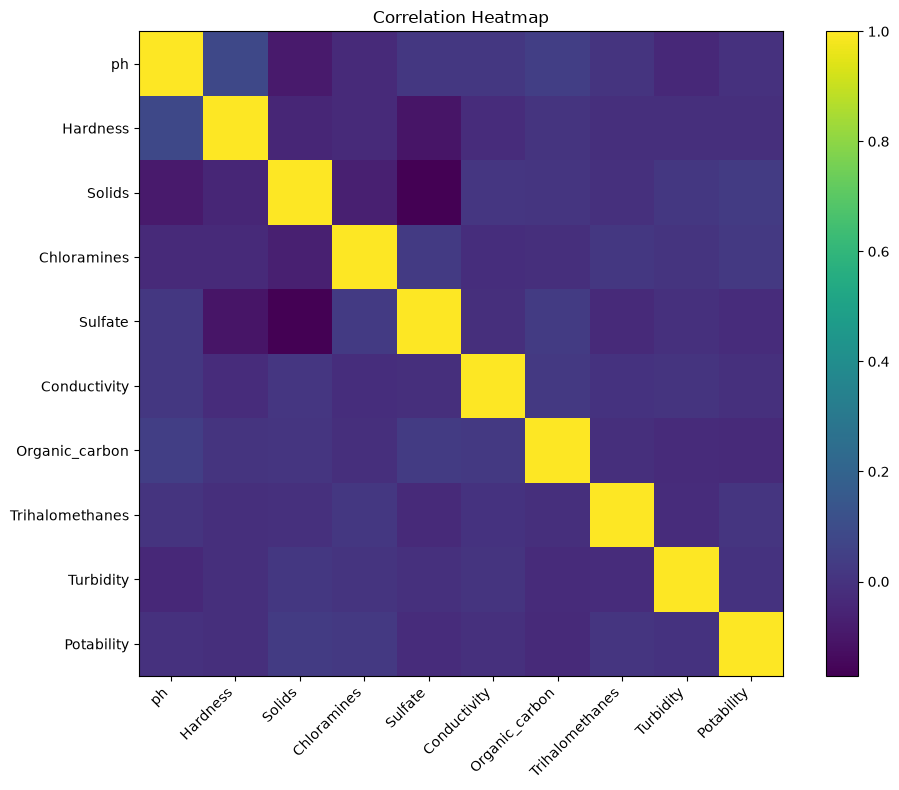

In [7]:
# ============================================
# Step 5: Data Visualization
# ============================================

# 5.1 Distribution of the target variable
plt.figure(figsize=(6, 4))

df["Potability"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Water Potability")
plt.xlabel("Potability")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Not Potable", "Potable"], rotation=0)
plt.tight_layout()
plt.show()


# 5.2 Histograms of water-quality features
df[feature_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Water Quality Features")
plt.tight_layout()
plt.show()


# 5.3 Boxplots of water-quality features
plt.figure(figsize=(14, 7))

df[feature_columns].boxplot()

plt.title("Boxplots of Water Quality Features")
plt.xlabel("Water Quality Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5.4 Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation_matrix)


# 5.5 Correlation heatmap
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
# ============================================
# Step 6: Prepare Features and Target
# ============================================

# Define the input features
feature_columns = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

# Create the feature matrix (X)
X = df[feature_columns]

# Create the target variable (y)
y = df["Potability"]

# Display the shape of X and y
print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

# Display the first 5 rows of the features
print("\nFirst 5 Rows of Features:")
print(X.head())

# Display the first 5 target values
print("\nFirst 5 Target Values:")
print(y.head())

Features (X) Shape: (3276, 9)
Target (y) Shape: (3276,)

First 5 Rows of Features:
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  
0       10.379783        86.990970   2.963135  
1       15.180013        56.329076   4.500656  
2       16.868637        66.420093   3.055934  
3       18.436524       100.341674   4.628771  
4       11.558279        31.997993   4.075075  

First 5 Target Values:
0    0
1    0
2    0
3    0
4    0
Name: Potability, dtype: int64


In [9]:
# ============================================
# Step 7: Train/Test Split
# ============================================

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)



Training Features Shape: (2620, 9)
Testing Features Shape: (656, 9)
Training Target Shape: (2620,)
Testing Target Shape: (656,)


In [10]:
# ============================================
# Step 8: Imputation and Feature Scaling
# ============================================

# Create the SimpleImputer
imputer = SimpleImputer(strategy="median")

# Fit the imputer using only the training data
# and transform the training features
X_train_imputed = imputer.fit_transform(X_train)

# Transform the testing features
# using the imputer fitted on the training data
X_test_imputed = imputer.transform(X_test)

# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler using only the training data
# and transform the training features
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Transform the testing features
# using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test_imputed)

# Display the first 5 rows of the scaled training data
print("First 5 Rows of Scaled Training Data:")
print(X_train_scaled[:5])

# Display the shape of the scaled datasets
print("\nScaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

First 5 Rows of Scaled Training Data:
[[ 5.05287688e-01  3.71294580e-01  4.80398455e-02 -7.91808689e-01
   2.05230791e+00  9.25183047e-01  5.65242368e-01 -3.65393479e-01
  -1.77456640e-01]
 [-7.09433207e-01  9.35083649e-01 -1.01608039e+00  8.50916640e-01
   1.61777683e+00 -1.50169330e+00 -2.16944822e+00 -1.58140352e+00
  -4.86501580e-01]
 [ 9.29048386e-01  9.80710337e-01  8.08192289e-01 -5.85714184e-01
  -1.92158854e-02 -8.18137199e-01  8.54040187e-02 -3.51573461e-01
   5.47201803e-01]
 [-2.27727800e-01  6.71247757e-01 -1.85296169e-03  3.07377083e-02
  -1.92158854e-02 -6.77954595e-01  7.74860809e-01  5.01623012e-01
  -9.15543160e-02]
 [-3.90242095e-01  1.76673280e-01 -5.48156095e-01 -5.71875046e-01
  -1.96177353e-01  6.65478506e-01  6.86438488e-01 -1.26382646e+00
  -5.44745829e-01]]

Scaled Training Data Shape: (2620, 9)
Scaled Testing Data Shape: (656, 9)


In [11]:
# ============================================
# Step 9: Logistic Regression
# ============================================

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

# Display the results
print("============================================")
print("Logistic Regression Results")
print("============================================")

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
Accuracy : 0.6097560975609756
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



d:\EGATE_AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\EGATE_AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\EGATE_AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\EGATE_AI\venv\Lib\site-packages\sklearn\metrics\_classifi

In [12]:
# ============================================
# Step 10: Decision Tree
# ============================================

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the Decision Tree
decision_tree_model.fit(X_train_imputed, y_train)

# Make predictions on the test data
y_pred_tree = decision_tree_model.predict(X_test_imputed)

# Calculate evaluation metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

# Display the results
print("============================================")
print("Decision Tree Results")
print("============================================")

print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
Accuracy : 0.5960365853658537
Precision: 0.48132780082987553
Recall   : 0.453125
F1 Score : 0.46680080482897385

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.69      0.67       400
           1       0.48      0.45      0.47       256

    accuracy                           0.60       656
   macro avg       0.57      0.57      0.57       656
weighted avg       0.59      0.60      0.59       656



In [13]:
# ============================================
# Step 11: Random Forest
# ============================================

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the Random Forest
random_forest_model.fit(X_train_imputed, y_train)

# Make predictions on the test data
y_pred_rf = random_forest_model.predict(X_test_imputed)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Display the results
print("============================================")
print("Random Forest Results")
print("============================================")

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.663109756097561
Precision: 0.6446280991735537
Recall   : 0.3046875
F1 Score : 0.41379310344827586

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



In [14]:
# ============================================
# Step 12: Support Vector Machine (SVM)
# ============================================

# Create the SVM model
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# Train the SVM using the scaled training data
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate evaluation metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

# Display the results
print("============================================")
print("Support Vector Machine (SVM) Results")
print("============================================")

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

d:\EGATE_AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Machine (SVM) Results
Accuracy : 0.6707317073170732
Precision: 0.7040816326530612
Recall   : 0.26953125
F1 Score : 0.3898305084745763

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



In [15]:
# ============================================
# Step 13: XGBoost
# ============================================

# Create the XGBoost classification model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

# Train the XGBoost model
xgb_model.fit(X_train_imputed, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test_imputed)

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

# Display the results
print("============================================")
print("XGBoost Results")
print("============================================")

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy : 0.6600609756097561
Precision: 0.6434782608695652
Recall   : 0.2890625
F1 Score : 0.39892183288409705

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       400
           1       0.64      0.29      0.40       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.66      0.66      0.62       656



In [16]:
# ============================================
# Step 14: Model Comparison
# ============================================

# Create a dictionary containing the performance
# of all five machine-learning models

model_results = {
    "Logistic Regression": {
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1 Score": logistic_f1
    },

    "Decision Tree": {
        "Accuracy": tree_accuracy,
        "Precision": tree_precision,
        "Recall": tree_recall,
        "F1 Score": tree_f1
    },

    "Random Forest": {
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1
    },

    "SVM": {
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1 Score": svm_f1
    },

    "XGBoost": {
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1 Score": xgb_f1
    }
}


# Convert the results into a DataFrame
results_df = pd.DataFrame(model_results).T

# Display the comparison table
print("============================================")
print("Model Performance Comparison")
print("============================================")

print(results_df)



# Find the best model based on F1 Score
best_model_name = results_df["F1 Score"].idxmax()
best_f1_score = results_df["F1 Score"].max()

print("\n============================================")
print("Best Model")
print("============================================")

print("Best Model Based on F1 Score:", best_model_name)
print("Best F1 Score:", round(best_f1_score, 4))

Model Performance Comparison
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.609756   0.000000  0.000000  0.000000
Decision Tree        0.596037   0.481328  0.453125  0.466801
Random Forest        0.663110   0.644628  0.304688  0.413793
SVM                  0.670732   0.704082  0.269531  0.389831
XGBoost              0.660061   0.643478  0.289062  0.398922

Best Model
Best Model Based on F1 Score: Decision Tree
Best F1 Score: 0.4668



Logistic Regression
Confusion Matrix:
[[400   0]
 [256   0]]


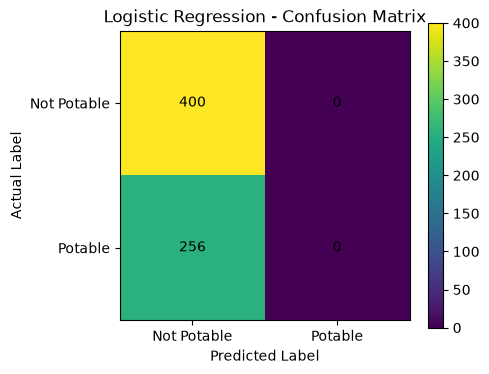


Decision Tree
Confusion Matrix:
[[275 125]
 [140 116]]


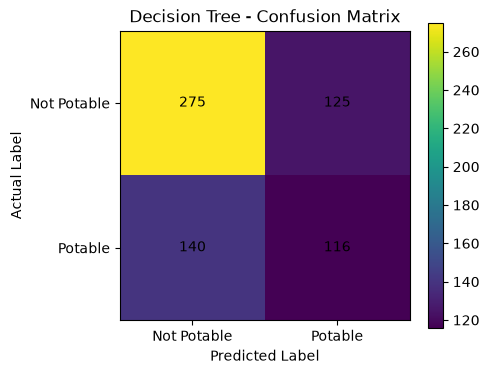


Random Forest
Confusion Matrix:
[[357  43]
 [178  78]]


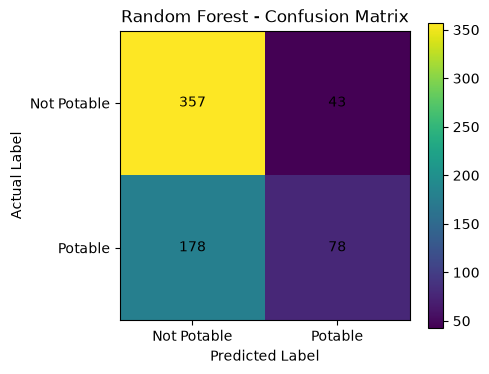


SVM
Confusion Matrix:
[[371  29]
 [187  69]]


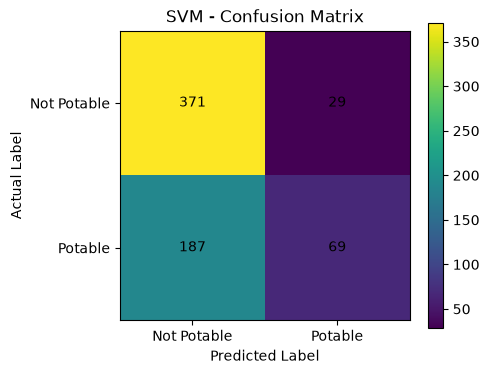


XGBoost
Confusion Matrix:
[[359  41]
 [182  74]]


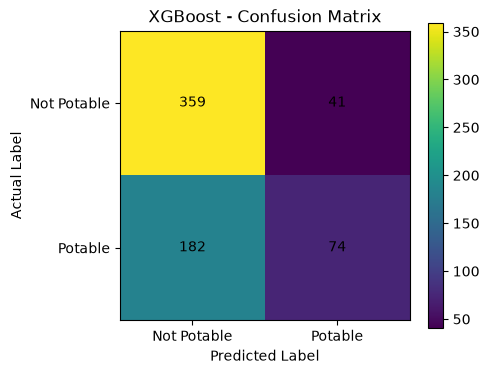

In [17]:
# ============================================
# Step 15: Confusion Matrix
# ============================================

# Create confusion matrices for all five models

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

# Generate a confusion matrix for each model
for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    print("\n============================================")
    print(model_name)
    print("============================================")

    print("Confusion Matrix:")
    print(cm)

    # Display the confusion matrix graphically
    plt.figure(figsize=(5, 4))

    plt.imshow(cm, interpolation="nearest")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.colorbar()

    plt.xticks(
        [0, 1],
        ["Not Potable", "Potable"]
    )

    plt.yticks(
        [0, 1],
        ["Not Potable", "Potable"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    # Add the numerical values inside the matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

ROC-AUC Results
Logistic Regression AUC: 0.5481
Decision Tree AUC: 0.5703
Random Forest AUC: 0.6411
SVM AUC: 0.6487
XGBoost AUC: 0.6592


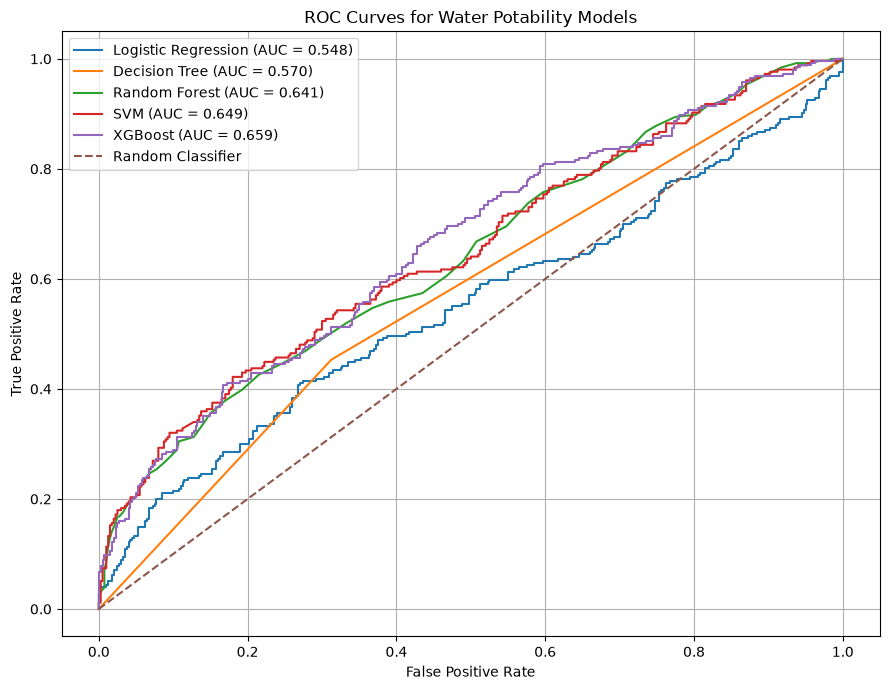

In [18]:
# ============================================
# Step 16: ROC Curve and AUC
# ============================================

# Get probability scores for Potable = 1

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

y_prob_tree = decision_tree_model.predict_proba(X_test_imputed)[:, 1]

y_prob_rf = random_forest_model.predict_proba(X_test_imputed)[:, 1]

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

y_prob_xgb = xgb_model.predict_proba(X_test_imputed)[:, 1]


# Put all model probabilities into one dictionary

models_probabilities = {
    "Logistic Regression": y_prob_logistic,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf,
    "SVM": y_prob_svm,
    "XGBoost": y_prob_xgb
}


# Display AUC scores and plot ROC curves

print("============================================")
print("ROC-AUC Results")
print("============================================")

plt.figure(figsize=(9, 7))

for model_name, probabilities in models_probabilities.items():

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, probabilities)

    # Calculate AUC
    auc_score = roc_auc_score(y_test, probabilities)

    print(f"{model_name} AUC: {auc_score:.4f}")

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )


# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves for Water Potability Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [19]:
# ============================================
# Step 17: SVM Hyperparameter Tuning
# ============================================

# Define the parameter combinations to test
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

# Create the GridSearchCV object
grid = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Perform hyperparameter tuning
grid.fit(X_train_scaled, y_train)

# Display the best parameters
print("============================================")
print("SVM Hyperparameter Tuning")
print("============================================")

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid.best_score_, 4))


# Get the best SVM model
best_svm = grid.best_estimator_

# Make predictions using the tuned SVM
y_pred_tuned = best_svm.predict(X_test_scaled)

# Get probability predictions for ROC-AUC
y_prob_tuned = best_svm.predict_proba(X_test_scaled)[:, 1]


# Calculate evaluation metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

# Calculate ROC-AUC
tuned_auc = roc_auc_score(y_test, y_prob_tuned)


# Display tuned SVM results
print("\n============================================")
print("Tuned SVM Results")
print("============================================")

print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)
print("ROC-AUC  :", tuned_auc)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

d:\EGATE_AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM Hyperparameter Tuning

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross-Validation F1 Score:
0.5074

Tuned SVM Results
Accuracy : 0.6387195121951219
Precision: 0.5575757575757576
Recall   : 0.359375
F1 Score : 0.43705463182897863
ROC-AUC  : 0.6303125

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.82      0.73       400
           1       0.56      0.36      0.44       256

    accuracy                           0.64       656
   macro avg       0.61      0.59      0.59       656
weighted avg       0.62      0.64      0.62       656


Confusion Matrix:
[[327  73]
 [164  92]]


FINAL MODEL COMPARISON
           Logistic Regression  Decision Tree  Random Forest  Original SVM  \
Accuracy                0.6098         0.5960         0.6631        0.6707   
Precision               0.0000         0.4813         0.6446        0.7041   
Recall                  0.0000         0.4531         0.3047        0.2695   
F1 Score                0.0000         0.4668         0.4138        0.3898   
ROC-AUC                 0.5481         0.5703         0.6411        0.6487   

           Tuned SVM  XGBoost  
Accuracy      0.6387   0.6601  
Precision     0.5576   0.6435  
Recall        0.3594   0.2891  
F1 Score      0.4371   0.3989  
ROC-AUC       0.6303   0.6592  

BEST MODEL RESULTS
Best F1 Score Model: Decision Tree -> 0.4668
Best ROC-AUC Model: XGBoost -> 0.6592
Best Accuracy Model: Original SVM -> 0.6707


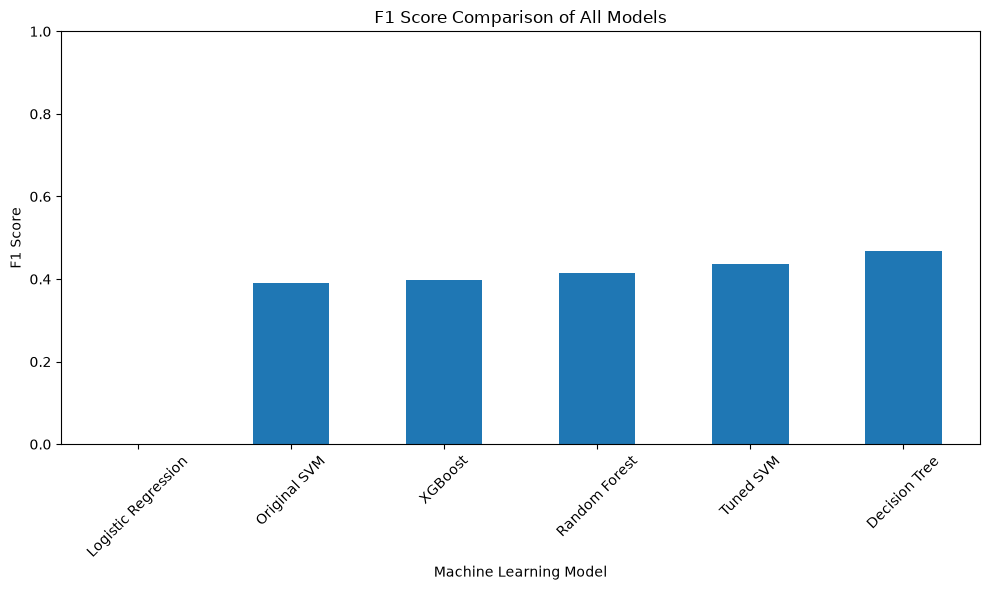

In [20]:
# ============================================
# Step 18: Final Model Comparison
# ============================================

# Calculate AUC for each model
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Create the final comparison table
final_results = pd.DataFrame({

    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        auc_logistic
    ],

    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        auc_tree
    ],

    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        auc_rf
    ],

    "Original SVM": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        auc_svm
    ],

    "Tuned SVM": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ],

    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        auc_xgb
    ]

}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
])

# Display the final comparison table
print("============================================")
print("FINAL MODEL COMPARISON")
print("============================================")
print(final_results.round(4))

# Find the best model according to F1 Score
best_model = final_results.loc["F1 Score"].idxmax()
best_f1 = final_results.loc["F1 Score"].max()

# Find the best model according to ROC-AUC
best_auc_model = final_results.loc["ROC-AUC"].idxmax()
best_auc = final_results.loc["ROC-AUC"].max()

# Find the best model according to Accuracy
best_accuracy_model = final_results.loc["Accuracy"].idxmax()
best_accuracy = final_results.loc["Accuracy"].max()

# Display the best models
print("\n============================================")
print("BEST MODEL RESULTS")
print("============================================")

print(
    "Best F1 Score Model:",
    best_model,
    "->",
    round(best_f1, 4)
)

print(
    "Best ROC-AUC Model:",
    best_auc_model,
    "->",
    round(best_auc, 4)
)

print(
    "Best Accuracy Model:",
    best_accuracy_model,
    "->",
    round(best_accuracy, 4)
)

# Create a bar chart for F1 Score comparison
plt.figure(figsize=(10, 6))

final_results.loc["F1 Score"].sort_values().plot(
    kind="bar"
)

plt.title("F1 Score Comparison of All Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Random Forest Feature Importance
           Feature  Importance
0               ph    0.129452
4          Sulfate    0.128327
1         Hardness    0.121530
3      Chloramines    0.115588
2           Solids    0.112325
8        Turbidity    0.100219
5     Conductivity    0.099791
6   Organic_carbon    0.096651
7  Trihalomethanes    0.096117


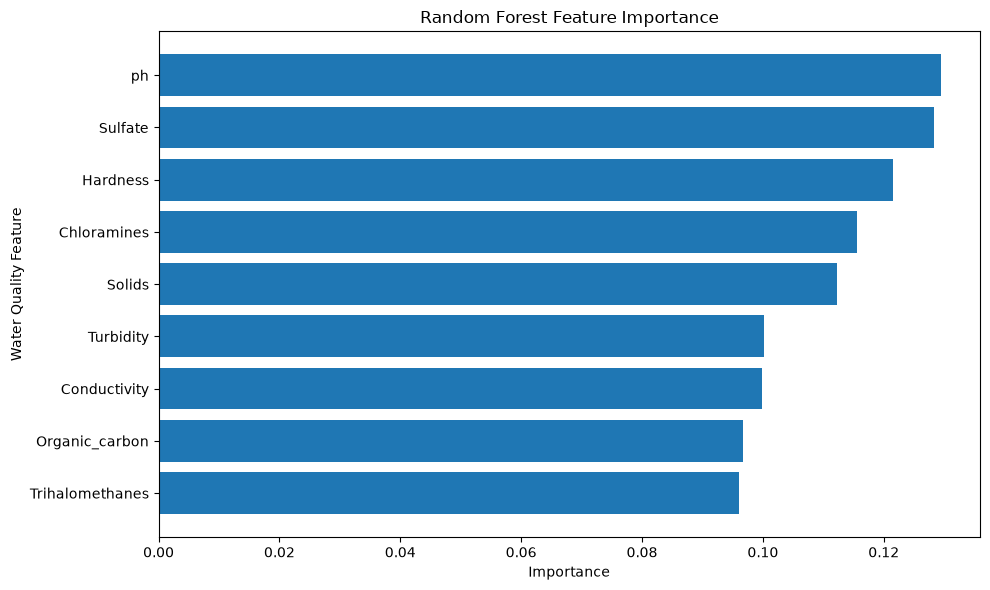


XGBoost Feature Importance
           Feature  Importance
4          Sulfate    0.167680
0               ph    0.162164
3      Chloramines    0.137287
1         Hardness    0.111026
2           Solids    0.106709
8        Turbidity    0.101067
5     Conductivity    0.074006
7  Trihalomethanes    0.073885
6   Organic_carbon    0.066175


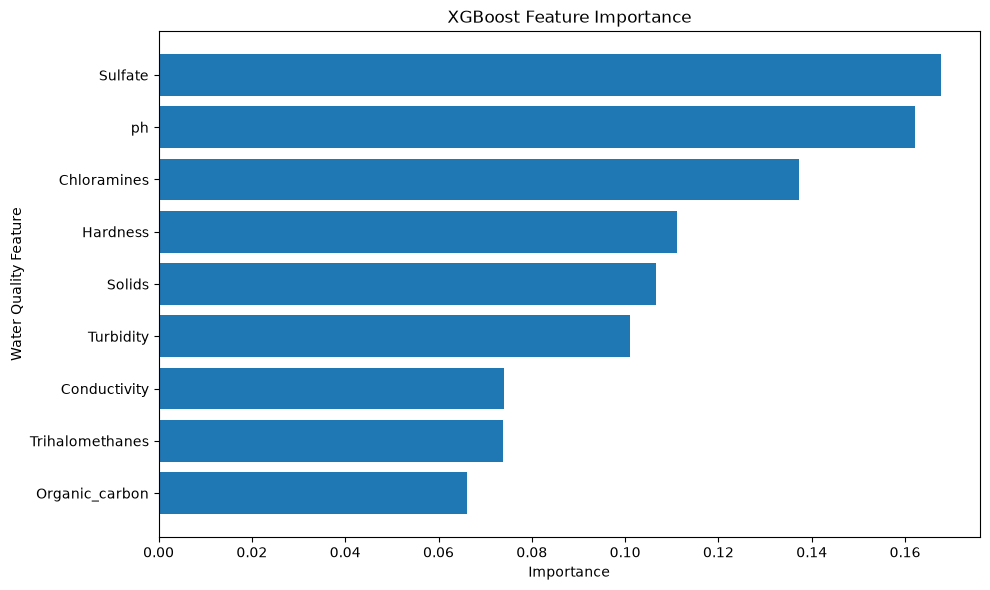


Top 3 Features - Random Forest
    Feature  Importance
0        ph    0.129452
4   Sulfate    0.128327
1  Hardness    0.121530

Top 3 Features - XGBoost
       Feature  Importance
4      Sulfate    0.167680
0           ph    0.162164
3  Chloramines    0.137287


In [21]:
# ============================================
# Step 19: Feature Importance
# ============================================

# Get the feature names
feature_names = X.columns


# ============================================
# Random Forest Feature Importance
# ============================================

# Get feature importance values from Random Forest
rf_importance = random_forest_model.feature_importances_

# Create a DataFrame for Random Forest importance
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
})

# Sort features from most important to least important
rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("============================================")
print("Random Forest Feature Importance")
print("============================================")

print(rf_importance_df)


# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance_df["Feature"],
    rf_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Water Quality Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ============================================
# XGBoost Feature Importance
# ============================================

# Get feature importance values from XGBoost
xgb_importance = xgb_model.feature_importances_

# Create a DataFrame for XGBoost importance
xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
})

# Sort features from most important to least important
xgb_importance_df = xgb_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n============================================")
print("XGBoost Feature Importance")
print("============================================")

print(xgb_importance_df)


# Plot XGBoost feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance_df["Feature"],
    xgb_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Water Quality Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ============================================
# Most Important Features
# ============================================

print("\n============================================")
print("Top 3 Features - Random Forest")
print("============================================")

print(
    rf_importance_df.head(3)
)


print("\n============================================")
print("Top 3 Features - XGBoost")
print("============================================")

print(
    xgb_importance_df.head(3)
)

FINAL MODEL EVALUATION
Selected Model: Decision Tree

Final Model Performance
Accuracy : 0.596
Precision: 0.4813
Recall   : 0.4531
F1 Score : 0.4668
ROC-AUC  : 0.5703

Classification Report
              precision    recall  f1-score   support

 Not Potable       0.66      0.69      0.67       400
     Potable       0.48      0.45      0.47       256

    accuracy                           0.60       656
   macro avg       0.57      0.57      0.57       656
weighted avg       0.59      0.60      0.59       656


Confusion Matrix
[[275 125]
 [140 116]]


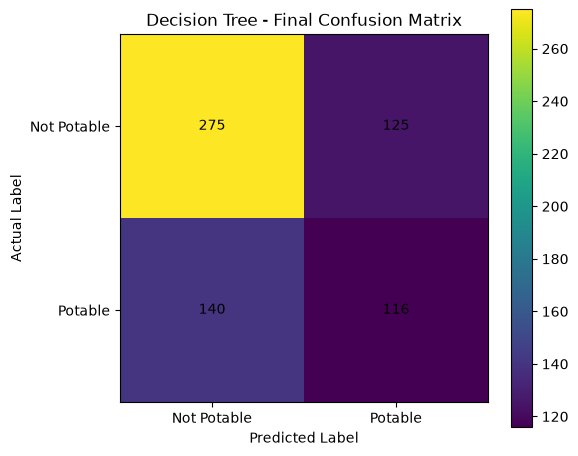

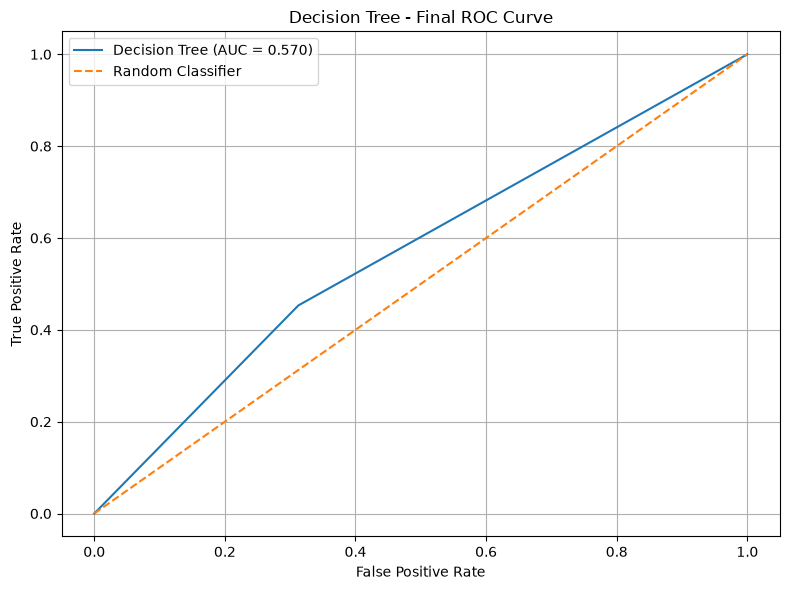

In [22]:
# ============================================
# Step 20: Final Model Evaluation
# ============================================

# Select the best model based on F1 Score
best_model_name = final_results.loc["F1 Score"].idxmax()

print("============================================")
print("FINAL MODEL EVALUATION")
print("============================================")

print("Selected Model:", best_model_name)


# ============================================
# Select the correct model and predictions
# ============================================

if best_model_name == "Logistic Regression":

    final_model = logistic_model
    final_predictions = y_pred_logistic
    final_probabilities = y_prob_logistic

elif best_model_name == "Decision Tree":

    final_model = decision_tree_model
    final_predictions = y_pred_tree
    final_probabilities = y_prob_tree

elif best_model_name == "Random Forest":

    final_model = random_forest_model
    final_predictions = y_pred_rf
    final_probabilities = y_prob_rf

elif best_model_name == "Original SVM":

    final_model = svm_model
    final_predictions = y_pred_svm
    final_probabilities = y_prob_svm

elif best_model_name == "Tuned SVM":

    final_model = best_svm
    final_predictions = y_pred_tuned
    final_probabilities = y_prob_tuned

elif best_model_name == "XGBoost":

    final_model = xgb_model
    final_predictions = y_pred_xgb
    final_probabilities = y_prob_xgb


# ============================================
# Calculate final evaluation metrics
# ============================================

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_auc = roc_auc_score(
    y_test,
    final_probabilities
)


# ============================================
# Display final metrics
# ============================================

print("\n============================================")
print("Final Model Performance")
print("============================================")

print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_auc, 4))


# ============================================
# Classification Report
# ============================================

print("\n============================================")
print("Classification Report")
print("============================================")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Not Potable",
            "Potable"
        ]
    )
)


# ============================================
# Confusion Matrix
# ============================================

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("\n============================================")
print("Confusion Matrix")
print("============================================")

print(final_cm)


# Plot the final confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(
    final_cm,
    interpolation="nearest"
)

plt.title(
    f"{best_model_name} - Final Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Not Potable", "Potable"]
)

plt.yticks(
    [0, 1],
    ["Not Potable", "Potable"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add numbers inside the matrix
for i in range(final_cm.shape[0]):
    for j in range(final_cm.shape[1]):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================
# Final ROC Curve
# ============================================

final_fpr, final_tpr, _ = roc_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    final_fpr,
    final_tpr,
    label=f"{best_model_name} (AUC = {final_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    f"{best_model_name} - Final ROC Curve"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# Step 21: Save the Final Model
# ============================================

import joblib

# ============================================
# Save the final model
# ============================================

joblib.dump(
    final_model,
    "water_potability_model.pkl"
)

# ============================================
# Save the imputer
# ============================================

joblib.dump(
    imputer,
    "water_potability_imputer.pkl"
)

# ============================================
# Save the feature names
# ============================================

joblib.dump(
    list(X.columns),
    "water_potability_features.pkl"
)

# ============================================
# Display confirmation
# ============================================

print("============================================")
print("MODEL SAVING")
print("============================================")

print("Final model saved as:")
print("water_potability_model.pkl")

print("\nImputer saved as:")
print("water_potability_imputer.pkl")

print("\nFeature names saved as:")
print("water_potability_features.pkl")

print("\nFinal model:", best_model_name)

print("\nModel and preprocessing files saved successfully!")

MODEL SAVING
Final model saved as:
water_potability_model.pkl

Imputer saved as:
water_potability_imputer.pkl

Feature names saved as:
water_potability_features.pkl

Final model: Decision Tree

Model and preprocessing files saved successfully!


In [24]:
# ============================================
# Step 22: Load Model and Make New Prediction
# ============================================

import joblib
import pandas as pd

# ============================================
# Load the saved model, imputer, and features
# ============================================

loaded_model = joblib.load(
    "water_potability_model.pkl"
)

loaded_imputer = joblib.load(
    "water_potability_imputer.pkl"
)

loaded_features = joblib.load(
    "water_potability_features.pkl"
)

# ============================================
# Enter new water-quality measurements
# ============================================

new_water_data = {
    "ph": 7.0,
    "Hardness": 200.0,
    "Solids": 20000.0,
    "Chloramines": 7.0,
    "Sulfate": 300.0,
    "Conductivity": 400.0,
    "Organic_carbon": 10.0,
    "Trihalomethanes": 60.0,
    "Turbidity": 4.0
}

# ============================================
# Convert the new data into a DataFrame
# ============================================

new_water_df = pd.DataFrame(
    [new_water_data]
)

# Make sure the features are in the same
# order used during model training

new_water_df = new_water_df[
    loaded_features
]

# ============================================
# Handle missing values
# ============================================

new_water_imputed = loaded_imputer.transform(
    new_water_df
)

# ============================================
# Make the prediction
# ============================================

prediction = loaded_model.predict(
    new_water_imputed
)

# ============================================
# Get prediction probability
# ============================================

prediction_probability = loaded_model.predict_proba(
    new_water_imputed
)[0][1]

# ============================================
# Display the result
# ============================================

print("============================================")
print("WATER POTABILITY PREDICTION")
print("============================================")

print("\nInput Water Measurements:")
print(new_water_df)

print("\nPrediction:")

if prediction[0] == 1:
    print("The water is predicted to be POTABLE.")
else:
    print("The water is predicted to be NOT POTABLE.")

print(
    "\nProbability of Potable Water:",
    round(prediction_probability * 100, 2),
    "%"
)

WATER POTABILITY PREDICTION

Input Water Measurements:
    ph  Hardness   Solids  Chloramines  Sulfate  Conductivity  Organic_carbon  \
0  7.0     200.0  20000.0          7.0    300.0         400.0            10.0   

   Trihalomethanes  Turbidity  
0             60.0        4.0  

Prediction:
The water is predicted to be POTABLE.

Probability of Potable Water: 100.0 %


In [25]:
# ============================================
# Step 23: Test Final Model with New Data
# ============================================

# Define the feature names
features = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

# ============================================
# Create several new water-quality samples
# ============================================

new_water_samples = pd.DataFrame({
    "ph": [7.0, 6.5, 8.0],
    "Hardness": [200.0, 150.0, 250.0],
    "Solids": [20000.0, 15000.0, 30000.0],
    "Chloramines": [7.0, 5.0, 8.0],
    "Sulfate": [300.0, 250.0, 350.0],
    "Conductivity": [400.0, 350.0, 500.0],
    "Organic_carbon": [10.0, 12.0, 15.0],
    "Trihalomethanes": [60.0, 50.0, 80.0],
    "Turbidity": [4.0, 3.0, 5.0]
})

# ============================================
# Make sure feature order is correct
# ============================================

new_water_samples = new_water_samples[
    features
]

# ============================================
# Handle missing values
# ============================================

new_water_imputed = imputer.transform(
    new_water_samples
)

# ============================================
# Make predictions
# ============================================

new_predictions = final_model.predict(
    new_water_imputed
)

# ============================================
# Get prediction probabilities
# ============================================

new_probabilities = final_model.predict_proba(
    new_water_imputed
)[:, 1]

# ============================================
# Create results table
# ============================================

prediction_results = new_water_samples.copy()

prediction_results["Prediction"] = new_predictions

prediction_results["Potable Probability"] = (
    new_probabilities
)

# ============================================
# Convert 0 and 1 into readable labels
# ============================================

prediction_results["Result"] = (
    prediction_results["Prediction"]
    .map({
        0: "Not Potable",
        1: "Potable"
    })
)

# ============================================
# Display results
# ============================================

print("============================================")
print("NEW WATER SAMPLE PREDICTIONS")
print("============================================")

print(
    prediction_results[
        [
            "Prediction",
            "Potable Probability",
            "Result"
        ]
    ]
)

NEW WATER SAMPLE PREDICTIONS
   Prediction  Potable Probability       Result
0           1                  1.0      Potable
1           0                  0.0  Not Potable
2           1                  1.0      Potable


In [26]:
# ============================================
# Step 24: Save Final Model for Deployment
# ============================================

import joblib
import os

# Save the final model
joblib.dump(final_model, "water_potability_model.pkl")

# Save the imputer used during preprocessing
joblib.dump(imputer, "water_potability_imputer.pkl")

# Save the feature names and their correct order
joblib.dump(list(features), "water_potability_features.pkl")

print("Final model and preprocessing files saved successfully.")

print("\nFinal Model:")
print(final_model)

print("\nFeatures:")
print(features)

print("\nSaved Files:")
print(
    "Model:",
    os.path.exists("water_potability_model.pkl")
)

print(
    "Imputer:",
    os.path.exists("water_potability_imputer.pkl")
)

print(
    "Features:",
    os.path.exists("water_potability_features.pkl")
)

Final model and preprocessing files saved successfully.

Final Model:
DecisionTreeClassifier(random_state=42)

Features:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Saved Files:
Model: True
Imputer: True
Features: True


In [38]:
# ============================================
# Step 25: Feature Ranges and Input Validation
# ============================================

# Define the allowed range for each feature
feature_ranges = {
    "ph": (0.0, 14.0),
    "Hardness": (47.432, 323.124),
    "Solids": (320.943, 61227.196),
    "Chloramines": (0.352, 13.127),
    "Sulfate": (129.0, 481.031),
    "Conductivity": (181.484, 753.343),
    "Organic_carbon": (2.2, 28.3),
    "Trihalomethanes": (0.738, 124.0),
    "Turbidity": (1.45, 6.739)
}

# ============================================
# Display Feature Ranges
# ============================================

print("============================================")
print("VALID FEATURE RANGES")
print("============================================")

for feature, (minimum, maximum) in feature_ranges.items():
    print(
        f"{feature}: {minimum} - {maximum}"
    )


# ============================================
# Input Validation Function
# ============================================

def validate_water_input(water_data):

    invalid_values = []

    for feature, (minimum, maximum) in feature_ranges.items():

        value = water_data[feature]

        if value < minimum or value > maximum:

            invalid_values.append(
                f"{feature}: {value} "
                f"(allowed range: {minimum} - {maximum})"
            )

    return invalid_values


print("\nFeature range validation is ready.")

VALID FEATURE RANGES
ph: 0.0 - 14.0
Hardness: 47.432 - 323.124
Solids: 320.943 - 61227.196
Chloramines: 0.352 - 13.127
Sulfate: 129.0 - 481.031
Conductivity: 181.484 - 753.343
Organic_carbon: 2.2 - 28.3
Trihalomethanes: 0.738 - 124.0
Turbidity: 1.45 - 6.739

Feature range validation is ready.


# Step 26: Final Project Summary


In [28]:
# ============================================
# Step 26: Final Project Summary
# ============================================

print("=" * 60)
print("       WATER POTABILITY PREDICTION PROJECT")
print("=" * 60)

print("\nPROJECT SUMMARY")
print("-" * 60)

print("Number of samples:", df.shape[0])
print("Number of features:", len(features))

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nTarget variable: Potability")
print("0 = Not Potable")
print("1 = Potable")

print("\nDATA PREPROCESSING")
print("-" * 60)
print("- Missing-value handling")
print("- Duplicate-value checking")
print("- Feature preparation")
print("- Train/test split")
print("- Feature scaling for Logistic Regression and SVM")

print("\nMACHINE LEARNING MODELS")
print("-" * 60)
print("- Logistic Regression")
print("- Decision Tree")
print("- Random Forest")
print("- Support Vector Machine (SVM)")
print("- XGBoost")

print("\nMODEL EVALUATION")
print("-" * 60)
print("- Accuracy")
print("- Precision")
print("- Recall")
print("- F1 Score")
print("- ROC-AUC")
print("- Confusion Matrix")
print("- ROC Curve")

print("\nFINAL MODEL")
print("-" * 60)
print("Selected model:", best_model_name)
print("Selection criterion: Highest F1 Score")
print("F1 Score:", round(best_f1_score, 4))

print("\nCONCLUSION")
print("-" * 60)

print(
    "Machine learning was applied to water-quality data as a "
    "binary classification problem. Five machine learning models "
    "were trained and evaluated using multiple performance metrics. "
    "The Decision Tree achieved the highest F1 Score and was "
    "therefore selected as the final model. The model was then "
    "saved for deployment."
)

print("\nProject completed successfully!")
print("=" * 60)

       WATER POTABILITY PREDICTION PROJECT

PROJECT SUMMARY
------------------------------------------------------------
Number of samples: 3276
Number of features: 9

Features used:
- ph
- Hardness
- Solids
- Chloramines
- Sulfate
- Conductivity
- Organic_carbon
- Trihalomethanes
- Turbidity

Target variable: Potability
0 = Not Potable
1 = Potable

DATA PREPROCESSING
------------------------------------------------------------
- Missing-value handling
- Duplicate-value checking
- Feature preparation
- Train/test split
- Feature scaling for Logistic Regression and SVM

MACHINE LEARNING MODELS
------------------------------------------------------------
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost

MODEL EVALUATION
------------------------------------------------------------
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

FINAL MODEL
------------------------------------------------------------
Selecte